# 🚨 Problem with Batch Gradient Descent

## Given:
- Number of rows: $n = 10^5$
- Number of epochs: $= 10^3$
- Number of columns: $10^2$
- Number of parameters (including bias): $101$

---

## Work per Epoch

- Work per parameter: $n = 10^5$ (since we need to compute the gradient for each parameter using all $n$ samples)
- Total parameters: $101$


$\text{Work per epoch} = 101 \times 10^5$



---

## Total Work


$\text{Total work} = 101 \times 10^5 \times 10^3 = 101 \times 10^8$

So, almost $10^{10}$ operations are needed for just one dataset, which is computationally expensive and time-consuming.

---

## ❌ Why Batch Gradient Descent is Not Good

- **High cost:** $\mathcal{O}(n \cdot p \cdot \text{epochs})$
- **Slow updates:** update only after full dataset pass
- **Not scalable:** large $n \Rightarrow$ huge computation
- **No online learning:** cannot handle streaming data
- **Memory issues:** needs to load entire dataset into memory (As we were doing vector operations of the whole dataset)

---

# Stochastic Gradient Descent (SGD) from Scratch

- **Key idea:** update parameters at every row instead of waiting for the full dataset
- So at each epoch, we perform $n$ updates instead of 1 as we did with Batch GD
- So more frequent update means faster convergence
- Also aapko ek iteration (epoch) mei ek row se bss matlab hai, so no need to load the entire dataset into memory, hence hardware requirements doesn't fail

### Stochastic means?

- It means randomness. So, we select the row randomly for each update

- Hence there is no **steady solution**, it means the way of convergence will vary every time we run the algorithm (It will take us to the answer but the path will be different every time as we are selecting the row randomly)

- There is benefit of this randomness, we will disuss it later

- Let's see the code now:



In [1]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import time

In [22]:
X,y = load_diabetes(return_X_y=True)

In [23]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [25]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [27]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.439933866156897

In [28]:
X_train

array([[-0.00188202, -0.04464164, -0.06979687, ..., -0.03949338,
        -0.06291688,  0.04034337],
       [-0.00914709, -0.04464164,  0.01103904, ..., -0.03949338,
         0.01703607, -0.0052198 ],
       [ 0.02354575,  0.05068012, -0.02021751, ..., -0.03949338,
        -0.09643495, -0.01764613],
       ...,
       [ 0.06350368,  0.05068012, -0.00405033, ..., -0.00259226,
         0.08449153, -0.01764613],
       [-0.05273755,  0.05068012, -0.01806189, ...,  0.1081111 ,
         0.03606033, -0.04249877],
       [ 0.00175052,  0.05068012,  0.05954058, ...,  0.1081111 ,
         0.06898589,  0.12732762]], shape=(353, 10))

In [29]:
X_train[0]

array([-0.00188202, -0.04464164, -0.06979687, -0.01255612, -0.00019301,
       -0.00914259,  0.07072993, -0.03949338, -0.06291688,  0.04034337])

In [41]:
class MySGDRegressor:
    
    def __init__(self,learning_rate=0.01,epochs=100):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            for j in range(X_train.shape[0]): # loop through all the rows 
                idx = np.random.randint(0,X_train.shape[0]) # generate a random index to select a random row
                
                y_hat = np.dot(X_train[idx],self.coef_) + self.intercept_ # Y_hat will be scalar not vector like in batch gradient descent
                
                intercept_slope = -2 * (y_train[idx] - y_hat) # instead of calculating the derivative for all the rows we are calculating it for one row only
                self.intercept_ = self.intercept_ - (self.lr * intercept_slope)
                
                coef_slope = -2 * np.dot((y_train[idx] - y_hat),X_train[idx]) # X_train[idx] is a complete row of the training data of that index (1,10) and (y_train[idx] - y_hat) is a scalar so the result will be a vector of shape (10,)
                # WHY ARE WE USING x_TRAIN[idx] ROW :
                # - So, earlier for 0th weight we used to use the X_train[:,0] column
                # - but now for updating the 0th weight we are using ony one single value of that column which is X_train[idx,0]
                # - and for 1st weight we are using X_train[idx,1] ,for 2nd weight we are using X_train[idx,2] and so on for all the weights 
                # - so, as we are using vectorized operation to update all the weights at once, we are using the complete row of the training data of that index which is X_train[idx] and it will give us a vector of shape (10,)

                self.coef_ = self.coef_ - (self.lr * coef_slope)
        
        print(self.intercept_,self.coef_)
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [ ]:
sgd = MySGDRegressor(learning_rate=0.01,epochs=50)
# Even if you don't change the learning rate and epochs, you will get different results every time you run the code because of the random index generation in the fit method which is used to select a random row from the training data for updating the weights and intercept.
# So, every time you run the code, you will be selecting different random rows from the training data for updating the weights and intercept which will lead to different results every time.

In [45]:
start = time.time()
sgd.fit(X_train,y_train)
print("The time taken is",time.time() - start)

153.2708212877645 [  59.83711137  -71.51567466  360.90952822  253.3305075    19.70873321
  -29.80049498 -164.81976887  124.29077724  321.12833474  131.72964476]
The time taken is 0.12951898574829102


- For same number of epochs, SGD will take more time than Batch GD because it is performing $n$ updates per epoch instead of 1, but it will converge faster than Batch GD because it is updating the parameters more frequently. So, it is a trade-off between time and convergence.

In [46]:
y_pred = sgd.predict(X_test)

In [47]:
r2_score(y_test,y_pred)

0.4340264636917188

# Implementing sklearn's SGDRegressor

In [35]:
from sklearn.linear_model import SGDRegressor

In [36]:
reg = SGDRegressor(max_iter=100,learning_rate='constant',eta0=0.01)

In [37]:
reg.fit(X_train,y_train)

c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",100
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [38]:
y_pred = reg.predict(X_test)

In [39]:
r2_score(y_test,y_pred)

0.43301048431355393

- All the animation are for 1 dimensional data
# Animation of change in line with each update

- The below animation is for one epoch, showing how the line changes with each update (each row) in that epoch. So, you can see the line is changing with each update

- The important thing to note that in stochastic gradient descent, It is not sure that $n+1$ th update will be better than $n$ th update, because in each update we are updating based on some randomly selected data point, so it is possible that the line gets worse after some update, but overall it will converge to the best fit line.

![best fit line animation](./stochastic_animation_line_plot2.gif)

- If you compare with batch gradient descent, there with each update (epoch) the line is improving, but in stochastic gradient descent, with each update (row) the line is changing and it may not be improving, but overall it will converge to the best fit line.

    - Animation of change in line with each epoch for batch gradient descent:
![best fit line animation](../D51-Gradient-descent/animations/animation4.gif)


## Animation of contour plot with each update

![contour plot animation](./stochastic_animation_contour_plot2.gif)

- In the above animation you can see that we didn't converge consistently towards the minimum like it was in batch gradient descent, but overall we are moving towards the minimum, which is the point where the cost function is minimum. So, in stochastic gradient descent, we are not guaranteed to move towards the minimum with each update, but overall we will converge to the minimum.

- See in the BGD how we consistently moved towards the minimum with each epoch

    ![BGD](../D51-Gradient-descent/animations/animation8.gif)


<span style="color:orange">**Main thing is that we need just 1 epoch in SGD to go near the minimum, while in BGD we need many epochs to go near the minimum, so overall SGD is faster than BGD in terms of convergence, but it is more computationally expensive than BGD because it is performing $n$ updates per epoch instead of 1. So, it is a trade-off between time and convergence.**
</span>

# Animation for cost function with each update

![cost function](./stochastic_animation_cost_plot.gif)

# When to use Stochastic Gradient Descent?

1. If you have big data then go for SGD

2. When you have a non-convex cost function, then go for SGD because it can help you to escape from local minima, while BGD will get stuck in local minima

    - (Like there is a possibility that the cost function has multiple minima, and BGD will get stuck in one of them, while SGD has a possibility to escape from it because of its randomness)

    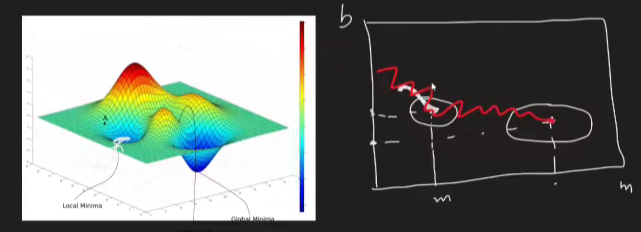

    - You have to carefully monitor the learning rate for this to work

- One more problem with SGD is that even after reaching near the minimum, it fluctuates, and fluctuate hoke kaha jayega iska koi idea nhi hota 

- To solve this problem, we can use a technique called **learning schedule**

## Learning Schedule

- We vary the learning rate with each epoch

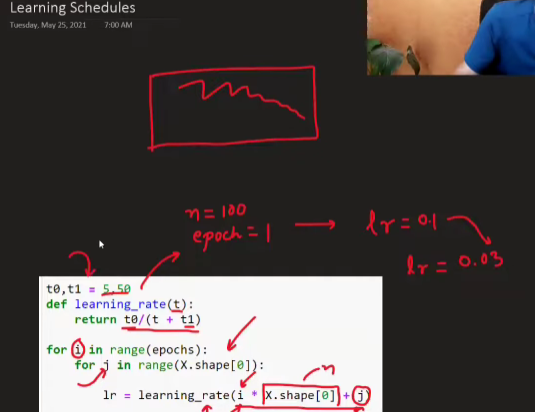

So, as learning rate decreases, the updates become smaller and smaller, which helps us to converge to the minimum and also helps us to reduce the fluctuations near the minimum.